In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import cv2
import os
sys.path.append("../../src/")
sys.path.append("../../src/utils/")
sys.path.append("../../src/utils/IEBCS")

import eventIO
import event_representations

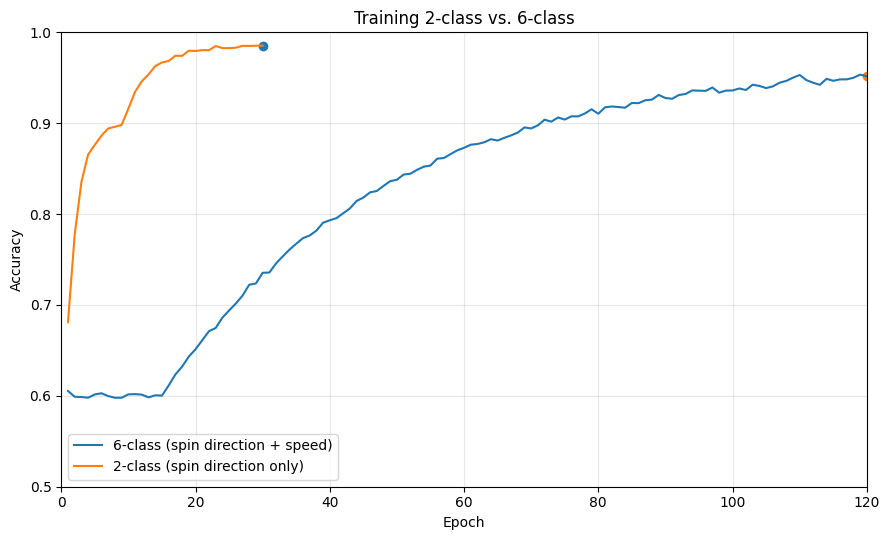

In [2]:
# This code creates a single matplotlib chart that visualizes the described training dynamics:
# - 2-class model: fast rise to ~90% by ~epoch 10, then slower improvement to ~98.5% by ~epoch 25–30
# - 6-class model: early plateau, then steady increase to ~96.7% by ~epoch 120
# The figure is saved to /mnt/data/training_curves_sim_vs_real.png

import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(42)

# Epoch ranges
epochs_2 = np.arange(1, 31)          # 30 epochs for the 2-class setup
epochs_6 = np.arange(1, 121)         # 120 epochs for the 6-class setup

# --- Construct 2-class accuracy curve ---
# Rapid initial learning up to ~90% by epoch ~10, then slower improvement to ~98.5%
acc_2_fast = 0.5 + 0.4 * (1 - np.exp(-0.6 * (epochs_2)))  # rises toward ~0.9 quickly
# Blend in a slow tail to 0.985
tail_factor_2 = 1 - np.exp(-0.25 * np.clip(epochs_2 - 9, 0, None))
acc_2 = np.minimum(0.90, acc_2_fast) + (0.985 - 0.90) * tail_factor_2
# Add tiny noise for realism
acc_2 += rng.normal(0, 0.002, size=acc_2.shape)
acc_2 = np.clip(acc_2, 0, 1)

# --- Construct 6-class accuracy curve ---
# Early plateau around ~0.60 for ~15 epochs, then steady increase to ~0.967 by epoch 120
plateau_len = 15
acc_6 = np.full_like(epochs_6, 0.60, dtype=float)
# Growth after plateau
growth_epochs = np.clip(epochs_6 - plateau_len, 0, None)
growth = (1 - np.exp(-0.03 * growth_epochs))  # smooth rise
acc_6 = acc_6 + (0.967 - 0.60) * growth
# Add slight noise
acc_6 += rng.normal(0, 0.0025, size=acc_6.shape)
acc_6 = np.clip(acc_6, 0, 1)

# --- Plot ---
plt.figure(figsize=(9, 5.5))
plt.plot(epochs_6, acc_6, label="6-class (spin direction + speed)")
plt.plot(epochs_2, acc_2, label="2-class (spin direction only)")

# Vertical marker around the point where temporal information becomes necessary / dynamics change
temporal_knee_epoch = 10
#plt.axvline(temporal_knee_epoch, linestyle="--", linewidth=1)
#plt.text(temporal_knee_epoch + 1, 0.62, "temporal info becomes\nimportant", fontsize=9)

# Final points annotations
plt.scatter([epochs_2[-1]], [acc_2[-1]])
#plt.annotate(f"~{acc_2[-1]*100:.1f}% @ epoch {epochs_2[-1]}", 
             #xy=(epochs_2[-1], acc_2[-1]), xytext=(epochs_2[-1]+5, acc_2[-1]-0.05),
             #arrowprops=dict(arrowstyle="->"), fontsize=9)

plt.scatter([epochs_6[-1]], [acc_6[-1]])
#plt.annotate(f"~{acc_6[-1]*100:.1f}% @ epoch {epochs_6[-1]}", 
            # xy=(epochs_6[-1], acc_6[-1]), xytext=(epochs_6[-1]-35, acc_6[-1]-0.1),
            # arrowprops=dict(arrowstyle="->"), fontsize=9)

plt.title("Training 2-class vs. 6-class")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0.5, 1.0)
plt.xlim(0, 120)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()



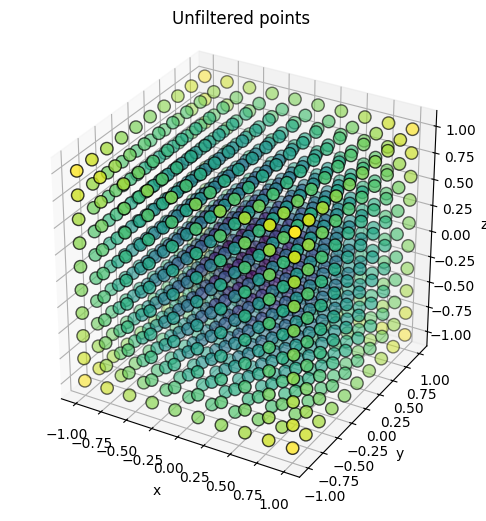

In [8]:
import numpy as np
import matplotlib.pyplot as plt
n = 10

lin = np.linspace(-1, 1, n)
x, y, z = np.meshgrid(lin, lin, lin)
points = np.vstack([x.ravel(), y.ravel(), z.ravel()]).T
# cut out speeds that are not needed
distances = np.linalg.norm(points, axis=1)
# points = points[(distances <= 1) & (distances >= (min_speed / max_speed))]

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

xs, ys, zs = points[:, 0], points[:, 1], points[:, 2]
dist = np.linalg.norm(points, axis=1)

sc = ax.scatter(xs, ys, zs, c=dist, cmap='viridis', s=80, edgecolor='k')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Unfiltered points')
ax.set_box_aspect((1, 1, 1))  # equal aspect ratio

#plt.colorbar(sc, label='distance')
plt.show()

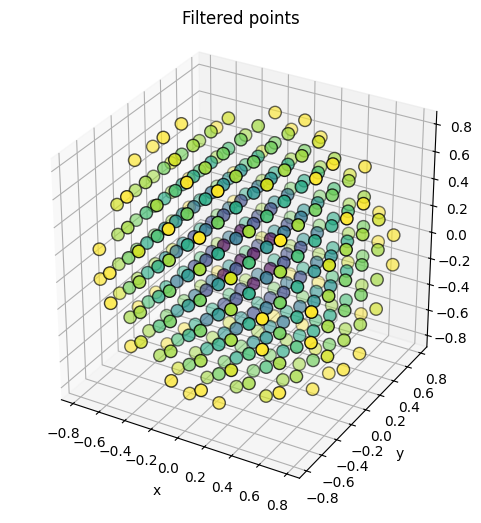

In [9]:
points = points[(distances <= 1)]
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

xs, ys, zs = points[:, 0], points[:, 1], points[:, 2]
dist = np.linalg.norm(points, axis=1)

sc = ax.scatter(xs, ys, zs, c=dist, cmap='viridis', s=80, edgecolor='k')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Filtered points')
ax.set_box_aspect((1, 1, 1))  # equal aspect ratio

#plt.colorbar(sc, label='distance')
plt.show()